# Entregable 3 — Análisis de Sentimientos en Tweets (3 clases, 2 modelos + TextBlob)

**Objetivo general:** Construir y evaluar modelos de análisis de sentimiento sobre tweets, trabajando con **tres clases** de polaridad:

- `0`: negativo  
- `2`: neutral  
- `4`: positivo  

Se trabaja con los datasets de Twitter provistos por la cátedra:

- `training.1600000.processed.noemoticon.csv` — dataset grande de entrenamiento (clases 0 y 4).  
- `testdata.manual.2009.06.14.csv` — dataset de evaluación manual (clases 0, 2 y 4).  

Según la consigna, se realizan los siguientes pasos:

1. Preprocesamiento y vectorización de texto.  
2. Construcción de un conjunto de entrenamiento con las clases 0, 2 y 4.  
3. Entrenamiento y evaluación de **al menos dos modelos supervisados** vistos en clase.  
4. Comparación contra un **modelo pre-entrenado** (TextBlob).  
5. Uso de al menos una métrica adicional (se incluye **similitud de coseno**).  
6. Presentación de resultados, decisiones tomadas y conclusiones (en celdas markdown).  


## 1. Importación de librerías

In [3]:
!pip install textblob spicy
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 16.2 MB/s eta 0:00:00


### 1.1. (Opcional) Instalación de TextBlob

In [4]:
# Si TextBlob no está instalado en el entorno, descomentar la siguiente línea:
# !pip install textblob

from textblob import TextBlob

## 2. Carga de los datasets

Se cargan los dos archivos indicados en la consigna.  
En esta notebook se asume que los archivos están en el mismo directorio que la notebook o se ajusta la ruta en las variables `train_path` y `test_path`.

Columnas según la descripción de la cátedra:

0 - `sentiment`: polaridad del tweet (0 = negativo, 2 = neutral, 4 = positivo)  
1 - `id`: id del tweet  
2 - `date`: fecha del tweet  
3 - `query`: término de búsqueda (o `NO_QUERY`)  
4 - `user`: nombre de usuario  
5 - `text`: texto del tweet  


In [5]:
train_path = "./training.1600000.processed.noemoticon.csv"  # ajustar ruta si es necesario
test_path = "./testdata.manual.2009.06.14.csv"              # ajustar ruta si es necesario

cols = ["sentiment", "id", "date", "query", "user", "text"]

# Se carga el dataset completo de entrenamiento (puede tardar, según entorno)
train_df = pd.read_csv(train_path, encoding="latin-1", names=cols)
test_df = pd.read_csv(test_path, encoding="latin-1", names=cols)

train_df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### 2.1. Distribución inicial de clases en el dataset de entrenamiento

In [6]:
train_df['sentiment'].value_counts()

sentiment
0    800000
4    800000
Name: count, dtype: int64

### 2.2. Distribución de clases en el dataset de test (etiquetado manual)

In [7]:
test_df['sentiment'].value_counts()

sentiment
4    182
0    177
2    139
Name: count, dtype: int64

## 3. Preprocesamiento de texto (inglés)

Los tweets están en inglés, por lo que el preprocesamiento se adapta a este idioma.

**Decisiones de limpieza:**

- Convertir todo a minúsculas para evitar duplicar palabras por diferencias de mayúsculas/minúsculas.  
- Eliminar menciones (`@usuario`) y URLs, ya que no aportan información directa de sentimiento.  
- Conservar solo palabras en inglés y **contracciones** (por ejemplo, `can't`, `don't`, `i'm`).  
  Esto evita errores como convertir `can't` en `can t`, que generaría tokens artificiales (`can`, `t`).  
- No se eliminan stopwords explícitamente; se confía en que TF-IDF reduzca su peso.


In [8]:
def limpiar_tweet(t):
    # Pasar a string y a minúsculas
    t = str(t).lower()
    # Eliminar menciones y URLs
    t = re.sub(r'@\w+', ' ', t)
    t = re.sub(r'http\S+|www\S+', ' ', t)
    # Mantener solo palabras en inglés y contracciones (can't, don't, i'm, etc.)
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", t)
    return " ".join(tokens)

train_df['clean'] = train_df['text'].apply(limpiar_tweet)
test_df['clean'] = test_df['text'].apply(limpiar_tweet)

train_df[['text', 'clean']].head()

,text,clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a that's a bummer you shoulda got david carr o...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...


## 4. Construcción del conjunto de entrenamiento (clases 0, 2, 4)

El dataset de entrenamiento original solo tiene clases **0** (negativo) y **4** (positivo).  
La consigna pide trabajar con tres clases de sentimiento (0, 2, 4), por lo que se construye una clase **neutral (2)** a partir del dataset de entrenamiento.

Se utiliza un enfoque **lexicón–basado sencillo**:

- Se define un pequeño conjunto de palabras claramente **positivas** (good, great, excellent, amazing, love, etc.).  
- Se define un conjunto análogo de palabras claramente **negativas** (bad, terrible, awful, hate, worst, etc.).  
- Para cada tweet se cuenta cuántas de estas palabras aparecen.  
- Se consideran **candidatos neutrales** aquellos tweets cuyo texto limpio no contiene ninguna palabra fuertemente positiva ni negativa según este lexicón reducido.


In [9]:
# Aseguramos que sentiment sea numérico
train_df['sentiment'] = train_df['sentiment'].astype(int)

positive_words = {
    'good','great','excellent','amazing','awesome','fantastic','love','like','nice',
    'happy','wonderful','best','favorite','enjoy','cool'
}

negative_words = {
    'bad','terrible','awful','horrible','hate','dislike','worst','sad','angry',
    'annoying','disappointed','boring','sucks','ugly','problem'
}

def count_sentiment_words(text):
    tokens = text.split()
    pos_count = sum(1 for w in tokens if w in positive_words)
    neg_count = sum(1 for w in tokens if w in negative_words)
    return pd.Series({'pos_count': pos_count, 'neg_count': neg_count})

sent_counts = train_df['clean'].apply(count_sentiment_words)
train_df = pd.concat([train_df, sent_counts], axis=1)

MAX_N = 50000  # ajustar según recursos

neg_all = train_df[train_df['sentiment'] == 0]
pos_all = train_df[train_df['sentiment'] == 4]

print('Negativos disponibles:', len(neg_all))
print('Positivos disponibles:', len(pos_all))

neutral_all = train_df[(train_df['pos_count'] == 0) & (train_df['neg_count'] == 0)]
print('Candidatos neutrales (sin palabras fuertes) disponibles:', len(neutral_all))

target = min(len(neg_all), len(pos_all), len(neutral_all), MAX_N)
print('Usaremos por clase:', target)

neg = neg_all.sample(target, random_state=42).copy()
pos = pos_all.sample(target, random_state=42).copy()
neutral = neutral_all.sample(target, random_state=42).copy()
neutral.loc[:, 'sentiment'] = 2

balanced_df = pd.concat([neg, neutral, pos], ignore_index=True)
balanced_df['sentiment'].value_counts()

Negativos disponibles: 800000
Positivos disponibles: 800000
Candidatos neutrales (sin palabras fuertes) disponibles: 1169449
Usaremos por clase: 50000


sentiment
0    50000
2    50000
4    50000
Name: count, dtype: int64

## 5. Vectorización con TF-IDF

Para poder entrenar un modelo de clasificación, es necesario transformar el texto en vectores numéricos.

**Decisión:** usar **TF-IDF**:

- TF (Term Frequency): frecuencia de aparición de un término en un documento.  
- IDF (Inverse Document Frequency): penaliza términos que aparecen en muchos documentos.  

De esta forma, cada tweet se representa como un vector de pesos TF-IDF.


In [10]:
vectorizer = TfidfVectorizer(max_features=50000)

X_train = vectorizer.fit_transform(balanced_df['clean'])
y_train = balanced_df['sentiment']

X_test = vectorizer.transform(test_df['clean'])
y_test = test_df['sentiment'].astype(int)

X_train.shape, X_test.shape

((150000, 50000), (498, 50000))

## 6. Modelos supervisados para análisis de sentimiento

Se entrenan y evalúan **dos modelos** clásicos vistos en clase sobre el mismo conjunto de features (TF-IDF):

1. **Logistic Regression** (multiclase).  
2. **Multinomial Naive Bayes** (modelo probabilístico clásico para texto).  

Luego se comparan sus métricas sobre el dataset de test manual.


### 6.1. Modelo 1 — Logistic Regression

In [11]:
logreg_model = LogisticRegression(
    max_iter=200,
    multi_class='multinomial',
    solver='lbfgs',
    n_jobs=-1
)

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

print('Reporte de clasificación — Logistic Regression (0 = negativo, 2 = neutral, 4 = positivo):\n')
print(classification_report(y_test, y_pred_logreg))

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Reporte de clasificación — Logistic Regression (0 = negativo, 2 = neutral, 4 = positivo):

              precision    recall  f1-score   support

           0       0.71      0.56      0.63       177
           2       0.42      0.43      0.43       139
           4       0.56      0.67      0.61       182

    accuracy                           0.57       498
   macro avg       0.57      0.56      0.56       498
weighted avg       0.58      0.57      0.57       498



### 6.2. Modelo 2 — Multinomial Naive Bayes

In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print('Reporte de clasificación — Multinomial Naive Bayes (0 = negativo, 2 = neutral, 4 = positivo):\n')
print(classification_report(y_test, y_pred_nb))

Reporte de clasificación — Multinomial Naive Bayes (0 = negativo, 2 = neutral, 4 = positivo):

              precision    recall  f1-score   support

           0       0.60      0.64      0.62       177
           2       0.41      0.33      0.37       139
           4       0.58      0.63      0.61       182

    accuracy                           0.55       498
   macro avg       0.53      0.53      0.53       498
weighted avg       0.54      0.55      0.54       498



### 6.3. Comparación resumida de accuracy entre modelos

In [13]:
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_nb = accuracy_score(y_test, y_pred_nb)

pd.DataFrame({
    'modelo': ['Logistic Regression', 'Multinomial NB'],
    'accuracy': [acc_logreg, acc_nb]
})

,modelo,accuracy
0,Logistic Regression,0.566265
1,Multinomial NB,0.550201


## 7. Matriz de confusión (modelo supervisado elegido)

Para profundizar en los errores, se muestra la matriz de confusión del modelo supervisado que se considere **más representativo** (por ejemplo, el de mayor accuracy entre Logistic Regression y Naive Bayes).


In [14]:
labels = [0, 2, 4]
cm = confusion_matrix(y_test, y_pred_logreg, labels=labels)
cm

array([[100,  45,  32],
       [ 17,  60,  62],
       [ 23,  37, 122]])

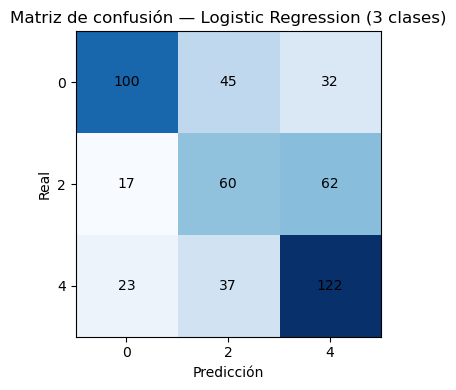

In [15]:
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — Logistic Regression (3 clases)')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## 8. Comparación con modelo pre-entrenado — TextBlob

La consigna sugiere comparar los modelos entrenados con al menos un **modelo pre-entrenado**.  
En este caso se utiliza **TextBlob**, que ya trae un modelo de análisis de sentimiento entrenado y devuelve:

- `polarity` en el rango [-1, 1] (negativo → positivo).  
- `subjectivity` en el rango [0, 1] (hecho → opinión).  

Para poder comparar contra nuestro problema de 3 clases (0, 2, 4), se define un mapeo simple:

- `polarity < -0.1`  → clase 0 (negativo)  
- `-0.1 ≤ polarity ≤ 0.1` → clase 2 (neutral)  
- `polarity > 0.1`  → clase 4 (positivo)  


In [16]:
def polarity_to_label(p):
    if p < -0.1:
        return 0
    elif p > 0.1:
        return 4
    else:
        return 2

textblob_polarities = test_df['text'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
textblob_pred = textblob_polarities.apply(polarity_to_label)

print('Reporte de clasificación — TextBlob (mapeado a clases 0/2/4):\n')
print(classification_report(y_test, textblob_pred))

Reporte de clasificación — TextBlob (mapeado a clases 0/2/4):

              precision    recall  f1-score   support

           0       0.85      0.44      0.58       177
           2       0.54      0.74      0.62       139
           4       0.64      0.76      0.70       182

    accuracy                           0.64       498
   macro avg       0.68      0.65      0.63       498
weighted avg       0.69      0.64      0.63       498



### 8.1. Comparación resumida: modelos entrenados vs TextBlob

In [17]:
acc_textblob = accuracy_score(y_test, textblob_pred)

pd.DataFrame({
    'modelo': ['Logistic Regression', 'Multinomial NB', 'TextBlob (pre-entrenado)'],
    'accuracy': [acc_logreg, acc_nb, acc_textblob]
})

,modelo,accuracy
0,Logistic Regression,0.566265
1,Multinomial NB,0.550201
2,TextBlob (pre-entrenado),0.640562


## 9. Métrica adicional: similitud de coseno entre tweets

La consigna requiere el uso de al menos una métrica como similitud de coseno, PMI, etc.  
Aquí se muestra un ejemplo sencillo de **similitud de coseno** aplicada a tweets individuales utilizando las representaciones TF-IDF.


Tweet NEGATIVO:
 Fuck this economy. I hate aig and their non loan given asses. 

Tweet NEUTRAL:
 Check this video out -- President Obama at the White House Correspondents' Dinner http://bit.ly/IMXUM 

Tweet POSITIVO:
 @stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right. 

Matriz de similitud de coseno entre ejemplos:


,negativo,neutral,positivo
negativo,1.000000,0.030226,0.00000
neutral,0.030226,1.000000,0.02275
positivo,0.000000,0.022750,1.00000


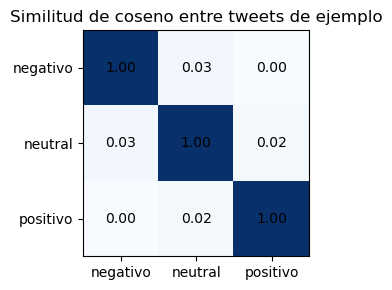

In [18]:
# Seleccionamos ejemplos de cada clase del set de test
ej_neg = test_df[test_df['sentiment'] == 0].iloc[0]
ej_neu = test_df[test_df['sentiment'] == 2].iloc[0]
ej_pos = test_df[test_df['sentiment'] == 4].iloc[0]

print('Tweet NEGATIVO:\n', ej_neg['text'], '\n')
print('Tweet NEUTRAL:\n', ej_neu['text'], '\n')
print('Tweet POSITIVO:\n', ej_pos['text'], '\n')

# Vectorizamos solo estos tres tweets
ejemplos = [ej_neg['clean'], ej_neu['clean'], ej_pos['clean']]
X_ej = vectorizer.transform(ejemplos)

sim_matrix = cosine_similarity(X_ej)

labels_sim = ['negativo', 'neutral', 'positivo']
sim_df = pd.DataFrame(sim_matrix, index=labels_sim, columns=labels_sim)
print('Matriz de similitud de coseno entre ejemplos:')
display(sim_df)

fig, ax = plt.subplots(figsize=(4,3))
im = ax.imshow(sim_matrix, cmap='Blues')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels_sim)
ax.set_yticklabels(labels_sim)
ax.set_title('Similitud de coseno entre tweets de ejemplo')

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## 10. Conclusiones

En esta sección se pueden redactar las conclusiones finales del trabajo, comentando:

- Qué modelo funcionó mejor y por qué.  
- Cómo se comportó la clase neutral en comparación con las otras.  
- Cómo se comparan los modelos entrenados contra TextBlob.  
- Limitaciones del enfoque (definición de neutral, mapeo de polarity, etc.).  
